In [1]:
import numpy as np

In [7]:
# we will see in the forms of vectors
house = np.array([1000,4,2,10]) # ==> single house a vector
print(house)
# shape of the house vector
print(house.shape) #==> (4,) WE CAN say it is 4 * 0 means 4 columns, 4 features on which it can be predicted

# Today: matrices
dataset = np.array([
    [1500, 3, 2, 10],   # house 1
    [2000, 4, 3,  5],   # house 2
    [1200, 2, 1, 15],   # house 3
])

print("matrix")
print(dataset)
#
print("shape")
print(dataset.shape) ## (3*4) 3 rows and 4 columns , where columns is feature

[1000    4    2   10]
(4,)
matrix
[[1500    3    2   10]
 [2000    4    3    5]
 [1200    2    1   15]]
shape
(3, 4)


### concpets

### Dot product revision:

Think of bias as a starting value

Imagine a salary formula:

salary = base_salary + (sales × commission)

Example:

salary = 20000 + (sales × 1000)

If someone sells 5 products:

salary = 20000 + 5000
       = 25000

Here:

Thing	ML term
base_salary	bias
commission	weight
sales	input feature

So:

👉 Bias = base value added to the result

Model weights

An ML model learns importance of each feature.

Example:

price increases with size

price increases with rooms

So model learns weights:

𝑤
=
[
200


10000
]
w=[
200
10000
	​

]

Meaning:

each sq ft adds ₹200
each room adds ₹10,000

In [11]:
a = np.array([1,2,3])
b = np.array([4,5,6])

# dot product
dot_result = np.dot(a,b)
print("dot result: ",dot_result)
print(f"Manual: (1×4)+(2×5)+(3×6) = {1*4}+{2*5}+{3*6} = {1*4+2*5+3*6}")

# Neural network uses this:
inputs  = np.array([0.5, 0.3, 0.8])   # one data row
weights = np.array([0.4, 0.7, 0.2])   # learned weights
bias    = 0.1                         # Bias is automatically learned by the model so predictions match real data better.

output = np.dot(inputs, weights) + bias
print(f"\nNeural net output: {output:.4f}")
print("This is what ONE neuron does")

dot result:  32
Manual: (1×4)+(2×5)+(3×6) = 4+10+18 = 32

Neural net output: 0.6700
This is what ONE neuron does


## Today's Core Concept: How Models Actually Learn

### The fit() and predict() mystery solved

Think of fit() like teaching a student.

teacher gives questions
student answers
teacher corrects
student improves

After many corrections:

student learns pattern

That learning process is model.fit().

✅ One line summary

👉 model.fit() = process where the model learns weights and bias from data by reducing prediction error.

Think of a student learning math.

During fit()
teacher shows many examples
student learns formula
During predict()
teacher gives new question
student uses learned formula

So:
_____________________
|Step |	What happens|
---------------------
|fit() |	learning|
--------------------------
|predict() |	using what was learned|
_____________________________

In [18]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=5)
# What does fit() actually do?
print("Before fit() — model knows nothing")
print("Starting training...\n")

model.fit(X_train, y_train)

print("After fit() — model has learned patterns")
print("It studied 120 flowers and found rules like:")
print("→ If petal length > 2.5 → probably not setosa")
print("→ If petal width > 1.8  → probably virginica")
print()

# What does predict() actually do?
sample = X_test[:3]  # one flower
prediction = model.predict(sample)
print(f"predict() — given new flower measurements:")
print(f"Measurements: {sample}")
for preds in prediction:
    print(f"Model says:   {data.target_names[preds]}")

Before fit() — model knows nothing
Starting training...

After fit() — model has learned patterns
It studied 120 flowers and found rules like:
→ If petal length > 2.5 → probably not setosa
→ If petal width > 1.8  → probably virginica

predict() — given new flower measurements:
Measurements: [[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]]
Model says:   versicolor
Model says:   setosa
Model says:   virginica


### Train test split deeply explained


EXAM ANALOGY:
─────────────────────────────────────────
Training data   = Practice questions
                  Student studies these

Validation data = Mock exam
                  Check if student is ready

Test data       = Real exam
                  Only taken ONCE at the end
                  Never seen during studying
─────────────────────────────────────────

If you test on training data:
→ Like giving student the exam answers
→ 100% score means nothing
→ Model just memorized, not learned



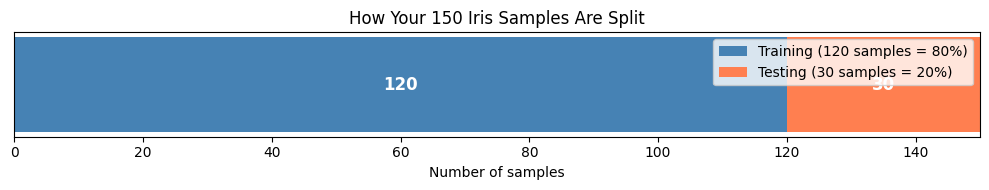

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# WHY do we split data?
# Simple analogy:

print("""
EXAM ANALOGY:
─────────────────────────────────────────
Training data   = Practice questions
                  Student studies these

Validation data = Mock exam
                  Check if student is ready

Test data       = Real exam
                  Only taken ONCE at the end
                  Never seen during studying
─────────────────────────────────────────

If you test on training data:
→ Like giving student the exam answers
→ 100% score means nothing
→ Model just memorized, not learned
""")

# Visualize the split
total    = 150
n_train  = int(total * 0.8)
n_test   = total - n_train

fig, ax = plt.subplots(figsize=(10, 2))

ax.barh(0, n_train, color='steelblue',
        label=f'Training ({n_train} samples = 80%)')
ax.barh(0, n_test, left=n_train, color='coral',
        label=f'Testing ({n_test} samples = 20%)')

ax.set_xlim(0, total)
ax.set_yticks([])
ax.set_xlabel('Number of samples')
ax.set_title('How Your 150 Iris Samples Are Split')
ax.legend(loc='upper right')

for i, (val, start, color) in enumerate([
    (n_train, 0, 'white'),
    (n_test, n_train, 'white')
]):
    ax.text(start + val/2, 0, str(val),
            ha='center', va='center',
            color=color, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## Linear Regression (Your First Regression Model)

### Classification (predicting a category)
Today = Regression (predicting a number)

In [21]:
# Classification → What TYPE is this?
#                  spam or not spam
#                  setosa or virginica

# Regression     → What NUMBER will this be?
#                  what PRICE will this house sell for?
#                  what SALARY will this person earn?

### Build house price predictor:

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create realistic house data
np.random.seed(42)
n_houses = 200

house_size   = np.random.randint(500, 3000, n_houses)
n_bedrooms   = np.random.randint(1, 6, n_houses)
house_age    = np.random.randint(1, 50, n_houses)

# Price formula (what we want model to discover)
# Price = size×150 + bedrooms×10000 - age×500 + noise
price = (house_size * 150 +
         n_bedrooms * 10000 -
         house_age * 500 +
         np.random.normal(0, 15000, n_houses))

df = pd.DataFrame({
    'size':     house_size,
    'bedrooms': n_bedrooms,
    'age':      house_age,
    'price':    price
})

print("=== House Dataset ===")
print(df.head(8))
print(df.columns)
print(df.shape)

print(f"price range is from max price: {df['price'].min()} to {df['price'].max()}" )

=== House Dataset ===
   size  bedrooms  age          price
0  1360         3   48  181548.791697
1  1794         2   21  287586.399887
2  1630         3   39  252478.938162
3  1595         3   36  255527.629870
4  2138         4   33  337121.203881
5  2669         4   30  428608.097168
6   966         1   37  129321.837138
7  1738         1   23  250857.282813
Index(['size', 'bedrooms', 'age', 'price'], dtype='str')
(200, 4)
price range is from max price: 72726.59858652079 to 488859.881915274


###  Visualize relationship:

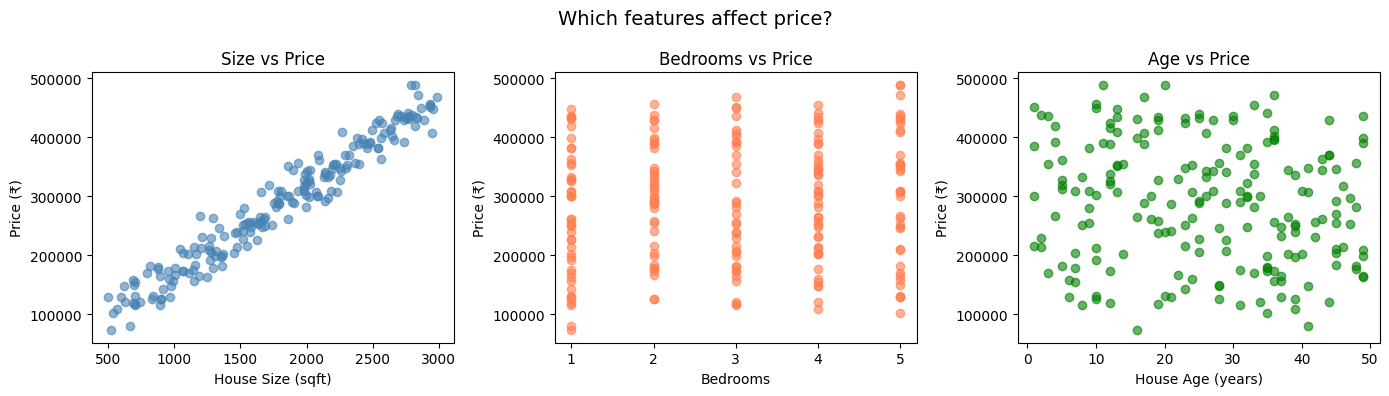

Notice:
→ Bigger size   = higher price (positive relationship)
→ More bedrooms = higher price (positive relationship)
→ Older house   = lower price  (negative relationship)


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Size vs Price
axes[0].scatter(df['size'], df['price'],
                alpha=0.6, color='steelblue')
axes[0].set_xlabel('House Size (sqft)')
axes[0].set_ylabel('Price (₹)')
axes[0].set_title('Size vs Price')

# Bedrooms vs Price
axes[1].scatter(df['bedrooms'], df['price'],
                alpha=0.6, color='coral')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price (₹)')
axes[1].set_title('Bedrooms vs Price')

# Age vs Price
axes[2].scatter(df['age'], df['price'],
                alpha=0.6, color='green')
axes[2].set_xlabel('House Age (years)')
axes[2].set_ylabel('Price (₹)')
axes[2].set_title('Age vs Price')

plt.suptitle('Which features affect price?', fontsize=14)
plt.tight_layout()
plt.show()

print("Notice:")
print("→ Bigger size   = higher price (positive relationship)")
print("→ More bedrooms = higher price (positive relationship)")
print("→ Older house   = lower price  (negative relationship)")

### Train Linear Regression:

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['size', 'bedrooms', 'age']]
y = df['price']
# split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
# Train
model = LinearRegression()
model.fit(X_train, y_train)
# What did model learn?
print("=== What Model Learned ===")
print("Formula: Price = ")
for feature, coef in zip(X.columns, model.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {direction} {feature:10} × {coef:,.0f}")
print(f"  + {model.intercept_:,.0f} (base price)\n")

print("Translation:")
print("→ Each extra sqft adds ₹{:,.0f}".format(model.coef_[0]))
print("→ Each bedroom adds   ₹{:,.0f}".format(model.coef_[1]))
print("→ Each year older     ₹{:,.0f}".format(model.coef_[2]))

=== What Model Learned ===
Formula: Price = 
  ↑ size       × 149
  ↑ bedrooms   × 10,014
  ↓ age        × -440
  + 2,071 (base price)

Translation:
→ Each extra sqft adds ₹149
→ Each bedroom adds   ₹10,014
→ Each year older     ₹-440


###  Evaluate the model:

=== Model Performance ===
R² Score: 0.975
RMSE:     ₹14,935

What these mean:
→ R² of 0.97 means model explains
  97% of price variation
→ RMSE of ₹14,935 means predictions
  are off by ~₹14,935 on average


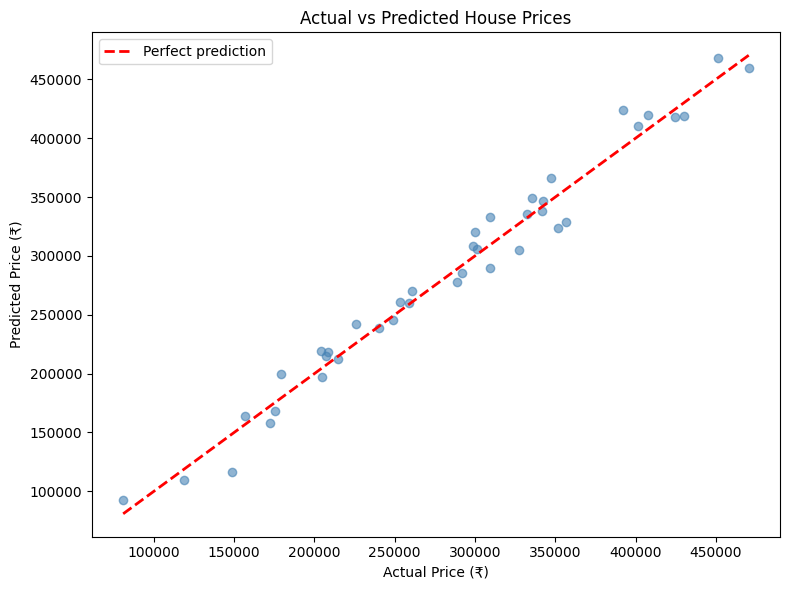

Closer dots are to red line = better model


In [47]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"R² Score: {r2:.3f}")
print(f"RMSE:     ₹{rmse:,.0f}")
print()
print("What these mean:")
print(f"→ R² of {r2:.2f} means model explains")
print(f"  {r2:.0%} of price variation")
print(f"→ RMSE of ₹{rmse:,.0f} means predictions")
print(f"  are off by ~₹{rmse:,.0f} on average")

# Visualize actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

print("Closer dots are to red line = better model")

####  Predict a new house:

In [52]:
# Real world usage — predict price of a new house
new_house = pd.DataFrame({
    'size':     [1800],   # 1800 sqft
    'bedrooms': [3],      # 3 bedrooms
    'age':      [10],     # 10 years old
})

predicted_price = model.predict(new_house)[0]
print("=== New House Prediction ===")
print(f"Size:          {new_house['size'][0]} sqft")
print(f"Bedrooms:      {new_house['bedrooms'][0]}")
print(f"Age:           {new_house['age'][0]} years")
print(f"Predicted Price: ₹{predicted_price:,.0f}")
print()
houses_to_try = pd.DataFrame({
    'size':     [500,  2000, 3000],
    'bedrooms': [1,    4,    5   ],
    'age':      [40,   5,    1   ],
})

predictions = model.predict(houses_to_try)
print("=== Multiple Predictions ===")
for i, (_, house) in enumerate(houses_to_try.iterrows()):
    print(f"House {i+1}: "
          f"{house['size']}sqft, "
          f"{house['bedrooms']}bed, "
          f"{house['age']}yr old "
          f"→ ₹{predictions[i]:,.0f}")

=== New House Prediction ===
Size:          1800 sqft
Bedrooms:      3
Age:           10 years
Predicted Price: ₹295,683

=== Multiple Predictions ===
House 1: 500sqft, 1bed, 40yr old → ₹68,927
House 2: 2000sqft, 4bed, 5yr old → ₹337,671
House 3: 3000sqft, 5bed, 1yr old → ₹498,316


array([295683.2155287])

### Build loan approval predictor:

In [53]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 300

# Simulate loan applicant data
salary      = np.random.randint(20000, 150000, n)
credit_score = np.random.randint(300, 850, n)
loan_amount  = np.random.randint(50000, 500000, n)
employment_years = np.random.randint(0, 20, n)

# Approval logic (what bank uses)
approved = (
    (credit_score > 650) &
    (salary > 40000) &
    (loan_amount < salary * 5)
).astype(int)

df_loan = pd.DataFrame({
    'salary':           salary,
    'credit_score':     credit_score,
    'loan_amount':      loan_amount,
    'employment_years': employment_years,
    'approved':         approved
})

print("=== Loan Dataset ===")
print(df_loan.head(8))
print(f"\nApproval rate: {approved.mean():.1%}")
print(f"Approved: {approved.sum()}, Rejected: {(1-approved).sum()}")

=== Loan Dataset ===
   salary  credit_score  loan_amount  employment_years  approved
0  141958           702       218152                16         1
1   35795           429       444540                 3         0
2   20860           352       403411                 0         0
3  123694           715       216981                 7         1
4  148106           546       270411                16         0
5  139879           738        69870                 2         1
6  130268           502       477794                19         0
7   96820           483       253196                14         0

Approval rate: 25.3%
Approved: 76, Rejected: 224


In [56]:
##preparing train data
X = df_loan.drop('approved', axis=1)
y = df_loan['approved']
X_train,X_test,y_train,y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

# Scale features — important for Logistic Regression
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [60]:
# Train
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
acc = model_lr.score(X_test_scaled, y_test)
print(f"Accuracy: {acc:.1%}\n")

Accuracy: 85.0%



In [61]:
# Predict probability for new applicant
new_applicant = pd.DataFrame({
    'salary':           [75000],
    'credit_score':     [720],
    'loan_amount':      [200000],
    'employment_years': [5]
})